# Assignment 7
### Do any five.

## 1. 

- What is the expected value of a single die roll? 
- What is the expected value of rolling two dice and adding the results together?
- What is the expected winnings of any gamble in European roulette?

- Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?
- Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

## 2. 
- Compute the expected value for a uniform random variable.
- Show that $\mathbb{E}[a+bX] = a + b\mathbb{E}[X]$
- Show, by example, that $v(\mathbb{E}[X]) \neq \mathbb{E}[v(X)]$, if $v(x) \neq a+bx$. For example, try $v(y) = y^2$ or $v(y)=\sqrt{y}$ with a Bernoulli or uniform or normally distributed random variable. This can be an important thing to remember: The expectation of a transformed random variable is not the transformation of the expected value.

## 3. 
- Compute the variance for a uniform random variable.
- Show that 
$$
\mathbb{V}[X] = \mathbb{E}[X^2] - \mathbb{E}[X]^2
$$
$$
\mathbb{V}[a+bX] = b^2 \mathbb{V}[X]
$$
- Show that if $X$ is a normally distributed random variable, then $a + bX$ is distributed normally with mean $a+ b \mathbb{E}[X]$ and variance $b^2 \sigma_X^2$ 

These properties get used all the time!


## 4.

- The **covariance** of $X$ and $Y$ is
$$
\text{cov}(X,Y) = \int_{y} \int_{x} (x-\mathbb{E}[X])(y-\mathbb{E}[Y])f_{XY}(x,y) dxdy = \mathbb{E}_{XY}[ (x-\mu_X)(y-\mu_Y)]
$$
- Show that if $f_{XY}(x,y)=f_X(x)f_Y(y)$, then $\text{cov}(X,Y)=0$
- Provide an example (computation/simulation is fine) where $\text{cov}(X,Y)\approx 0$ but $f_{XY}(x,y)\neq 0$
- The covariance doesn't characterize joint random variables except in a few special cases: The covariance only captures the **linear** association between the two variables, not nonlinear associations.

## 5. 

Suppose $X$ has an expectation $\mathbb{E}[X]<\infty$ and variance $\mathbb{V}[X]<\infty$; this isn't always true, but is *usually* true
- Consider making a new variable, $\varepsilon = X - \mathbb{E}[X]$
- What's the expectation of $\varepsilon$?
- What's the variance of $\varepsilon$?
- So we can write any random variable in the form $X = \mathbb{E}[X] + \varepsilon, $ where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon] = \sigma_X^2$
- If that's true, show that we can also write any random variable in the form $X = \mathbb{E}[X] + \sigma_X \varepsilon$, where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon]=1$
- Now replace $\mathbb{E}[X]$ with $x\beta$, and the stage is set for regression models

## 6.
- Use the Taylor series expansions 
$$
F(x+h) = F(x) + hf(x) + \frac{h^2}{2}f'(x) + O(h^3)
$$ 
and 
$$
F(x-h) = F(x) - h f(x) + \frac{h^2}{2} f'(x)+ O(h^3)
$$
to show that
$$
\mathbb{E}[\hat{f}_{X,h}(x)] = \frac{F(x+h)-F(x-h)}{2h} = f(x) + O(h^2),
$$
so the **bias** of the KDE is $O(h^2)$, unlike the ECDF, for which $\mathbb{E}[\hat{F}(x)] = F(x)$.

## 7.
- Suppose $X$ and $Y$ are distributed bivariate normal. Show that if $\rho=0$, then $X$ and $Y$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix, then $X_1, X_2, ..., X_n$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix and all the $\sigma_i^2$ and all the $\mu_i$ are equal, then $X_1, X_2, ..., X_n$ are independently distributed random variables with distribution $N(\mu, \sigma^2)$

## 8.
- Open the METABRIC data. Make a histogram of 'Ratio Therapy'.
- Let treatment, $T$ be distributed binomial with parameter $p$. Then the contribution to the likelihood for each patient $i$, with $y_i = 0$ for no radiation therapy and $y_i=1$ for radiation therapy, is 
$$
p^{y_i}(1-p)^{1-y_i}
$$
- Write out the likelihood.
- Maximize the likelihood with respect to $p$. What is the MLE, $\hat{p}$?
- Bootstrap the sampling density/distribution of $\hat{p}$.

answer source: https://github.com/ds4e/understanding_uncertainty_assignments/blob/main/assignment_7_solutions.ipynb

The likelihood is 
$$
L(p) = \prod_{i=1}^n p^{y_i}(1-p)^{1-y_i}
$$

To maximize, we first take logs:
$$
\ell(p) = \sum_{i=1}^n y_i \log(p) + (1-y_i) \log(1-p)
$$
and
$$
\ell'(p) = \sum_{i=1}^n y_i \frac{1}{p} - (1-y_i) \frac{1}{1-p}
$$
At the optimum, we have
$$
\sum_{i=1}^n y_i \frac{1}{\hat{p}} - (1-y_i) \frac{1}{1-\hat{p}} = 0
$$
Solving the first-order condition for $p$ yields the MLE
$$
\hat{p} = \dfrac{1}{n} \sum_{i=1}^n y_i.
$$

<Axes: xlabel='Radio Therapy', ylabel='Proportion'>

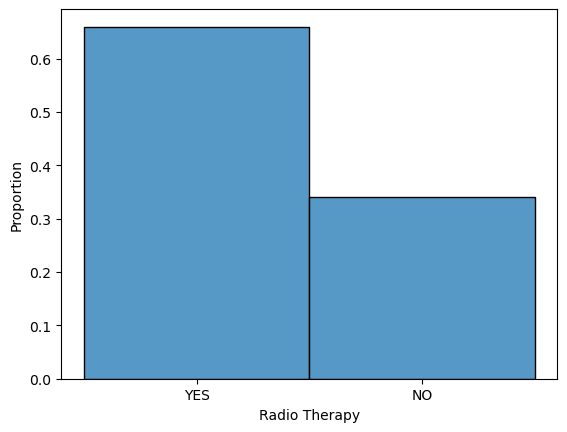

In [28]:
df = pd.read_csv('./data/metabric.csv')

y = df['Radio Therapy']
sns.histplot(y,stat='proportion')

MLE:  0.659717051377513


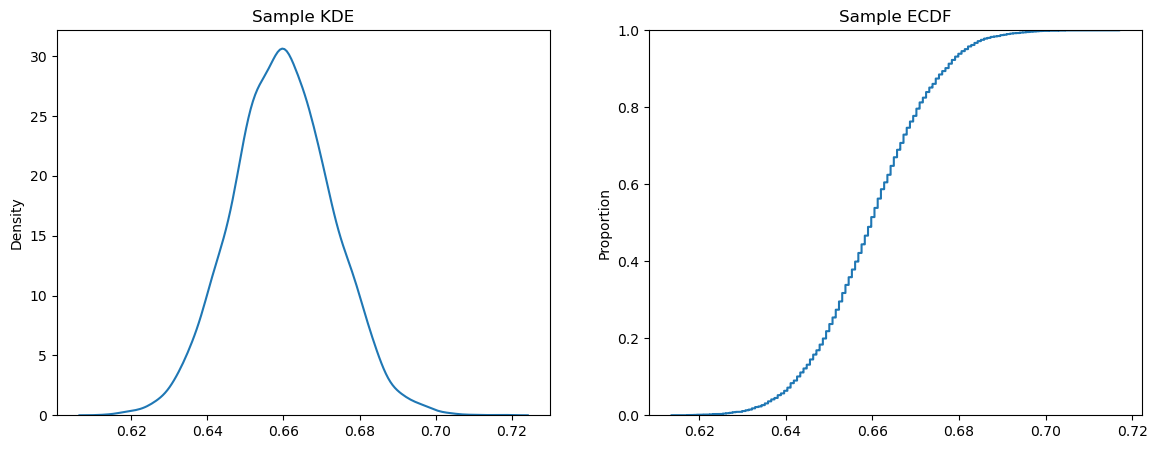

In [29]:
y = pd.to_numeric( y.replace({'NO':'0','YES':'1'}) , errors='coerce' ) # Convert string to numeric
print(f'MLE: ', y.mean())

S = 5000
sample = [ np.mean( y.sample(frac=1,replace=True) ) for s in range(S) ]

fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=sample,ax=axes[0],label='kde')
axes[0].set_title('Sample KDE')
sns.ecdfplot(x=sample,ax=axes[1],label='ecdf')
axes[1].set_title('Sample ECDF')
plt.show()

## 9.
- Open the Ames house price data. Make a KDE of 'price'. Select an appropriate distribution for modeling it, and explain why you selected it. (Hint: You might want to take a common transformation of price.)
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood. What is the MLE?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameters.

answer source: https://github.com/ds4e/understanding_uncertainty_assignments/blob/main/assignment_7_solutions.ipynb

Our density is
$$
f(y) = \dfrac{1}{\sqrt{2\pi} \sigma}e^{-\frac{1}{2}\left( \frac{y-\mu}{\sigma} \right)^2}
$$
and the likelihood is
$$
L(\mu, \sigma) = \prod_{i=1}^n \dfrac{1}{\sqrt{2\pi} \sigma}e^{-\frac{1}{2}\left( \frac{y_i-\mu}{\sigma} \right)^2}.
$$

To maximize the likelihood, we first take logs:
$$
\ell(\mu, \sigma) = \sum_{i=1}^n \log \left( \dfrac{1}{\sqrt{2\pi}}\right) - \log(\sigma) -\frac{1}{2}\left( \frac{y_i-\mu}{\sigma} \right)^2
$$
We then take the derivative with respect to each parameter:
$$
\dfrac{\partial \ell(\mu,\sigma)}{\partial \mu} = \sum_{i=1}^n  \frac{y_i-\mu}{\sigma^2}
$$
$$
\dfrac{\partial \ell(\mu,\sigma)}{\partial \sigma} = \sum_{i=1}^n  \frac{-1}{\sigma} +  \frac{(y_i-\mu)^2}{\sigma^3} 
$$
Setting these equal to zero and solving yields
$$
\hat{\mu} = \frac{1}{n}\sum_{i=1}^n y_i
$$
$$
\hat{\sigma} = \sqrt{ \frac{1}{n} \sum_{i=1}^n (y_i - \hat{\mu})^2 }
$$

<Axes: xlabel='price', ylabel='Proportion'>

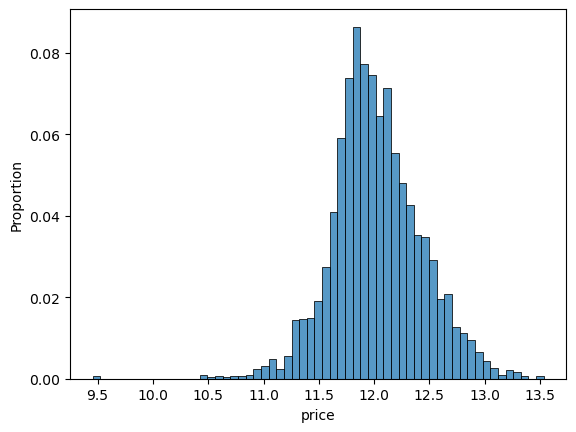

In [30]:
df = pd.read_csv('./data/ames_prices.csv')
y = np.log( df['price'] )
sns.histplot(y,stat='proportion')

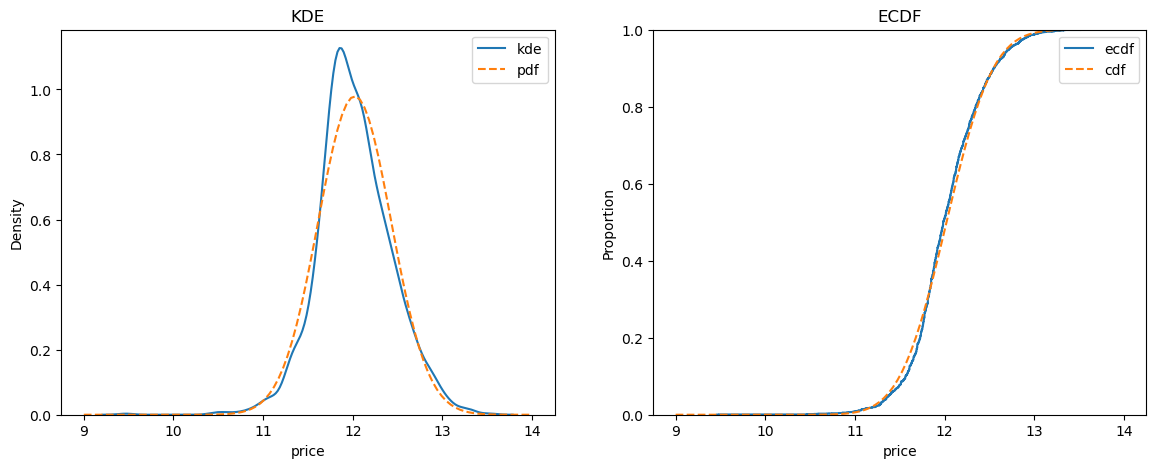

In [31]:
mu_hat = np.mean(y)
sigma_hat = np.sqrt( np.mean( (y-mu_hat)**2 ) )

grid = np.linspace(9,14,100)

pdf = sp.stats.norm.pdf(grid,loc=mu_hat,scale=sigma_hat)
cdf = sp.stats.norm.cdf(grid,loc=mu_hat,scale=sigma_hat)

fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=y,ax=axes[0],label='kde')
sns.lineplot(x=grid,y=pdf,ax=axes[0],label='pdf',linestyle='--')
axes[0].set_title('KDE')
sns.ecdfplot(x=y,ax=axes[1],label='ecdf')
sns.lineplot(x=grid,y=cdf,ax=axes[1],label='cdf',linestyle='--')
axes[1].set_title('ECDF')
plt.show()

ECDF: Actually looks really good

KDE: The kde has a bit of a higher peak than the pdf, and has a bit more of left skewing data.

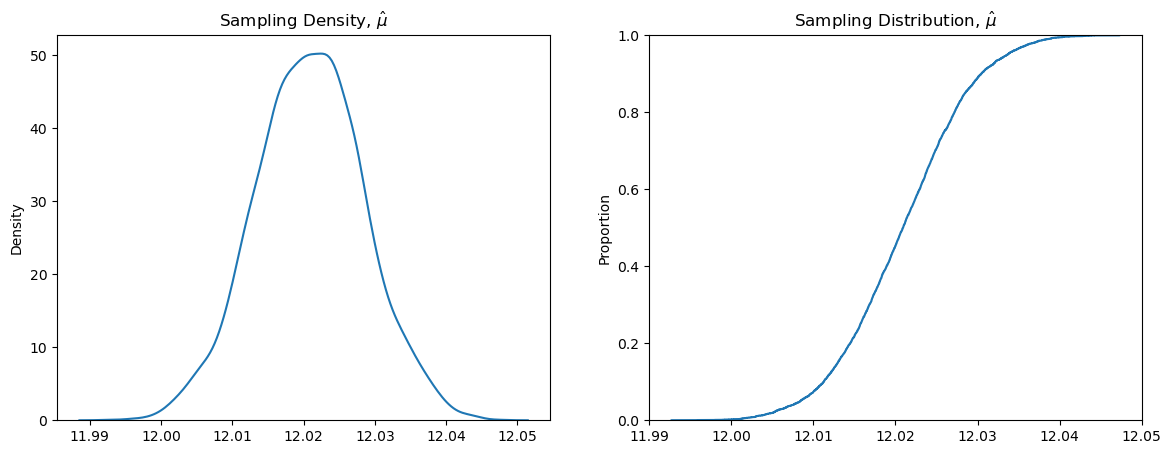

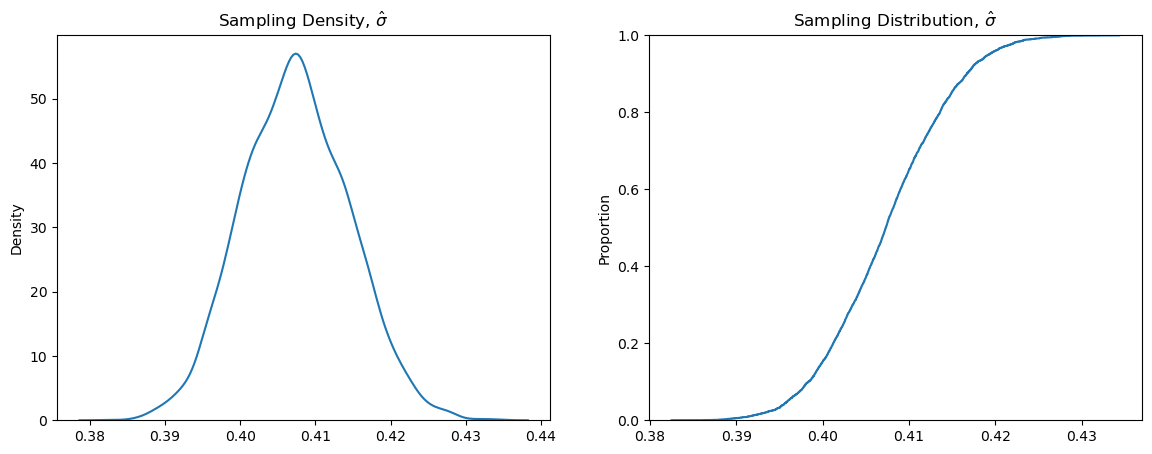

In [32]:
def mle(y):
    mu_hat = np.mean(y)
    sigma_hat = np.sqrt( np.mean( (y-mu_hat)**2 ) )
    return mu_hat, sigma_hat

# Bootstrapping:
S = 5000
sample = [ mle(y.sample(frac=1.0,replace=True)) for s in range(S)]

# Sampling distributions:
mu_hat_sample = [ row[0] for row in sample]
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=mu_hat_sample,ax=axes[0],label='kde')
axes[0].set_title('Sampling Density, $\\hat{\\mu}$')
sns.ecdfplot(x=mu_hat_sample,ax=axes[1],label='ecdf')
axes[1].set_title('Sampling Distribution, $\\hat{\\mu}$')
plt.show()

sigma_hat_samples = [ row[1] for row in sample]
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=sigma_hat_samples,ax=axes[0],label='kde')
axes[0].set_title('Sampling Density, $\\hat{\\sigma}$')
sns.ecdfplot(x=sigma_hat_samples,ax=axes[1],label='ecdf')
axes[1].set_title('Sampling Distribution, $\\hat{\\sigma}$')
plt.show()

## 10.
- Open the METABRIC data. Make a KDE of 'Overall Survival (Months)'.
- Let survival time, $T$ be distributed exponentially with parameter $\lambda$. Then its distribution is
$$
F(t) = 1 - e^{-\lambda t} = p[T\le t].
$$
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood with respect to $\lambda$. What is the MLE, $\hat{\lambda}$?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of $\hat{\lambda}$.

Density:

$$
f(t_i\mid\lambda)=\lambda e^{-\lambda t_i}.
$$

Likelihood:

$$
L(\lambda)
  = \prod_{i=1}^n \lambda e^{-\lambda t_i}
  = \lambda^n \exp\!\left(-\lambda\sum_{i=1}^n t_i\right).
$$

Log-likelihood:

$$
\ell(\lambda)
  = n\log\lambda - \lambda\sum_{i=1}^n t_i.
$$

Derivative:

$$
\frac{d\ell}{d\lambda}
  = \frac{n}{\lambda} - \sum_{i=1}^n t_i = 0
$$

$$
\hat{\lambda}
  = \frac{n}{\sum_{i=1}^n t_i}
  = \frac{1}{\bar{t}}.
$$


In [33]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy as sp


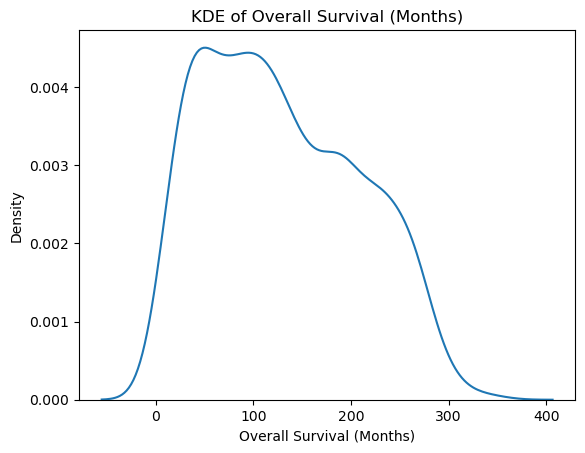

In [34]:
df = pd.read_csv('./data/metabric.csv')

y = df['Overall Survival (Months)'].dropna()
sns.kdeplot(x=y)
plt.xlabel('Overall Survival (Months)')
plt.title('KDE of Overall Survival (Months)')
plt.show()

In [35]:
y = df['Overall Survival (Months)'].dropna()
l_hat = 1 / y.mean()
print('MLE l_hat:', l_hat)


MLE l_hat: 0.007746275913926935


In [36]:
grid = np.linspace(0, y.max(), 200)

# Exponential pdf and cdf with l_hat
pdf = sp.stats.expon.pdf(grid, scale=1/l_hat)  
cdf = sp.stats.expon.cdf(grid, scale=1/l_hat)


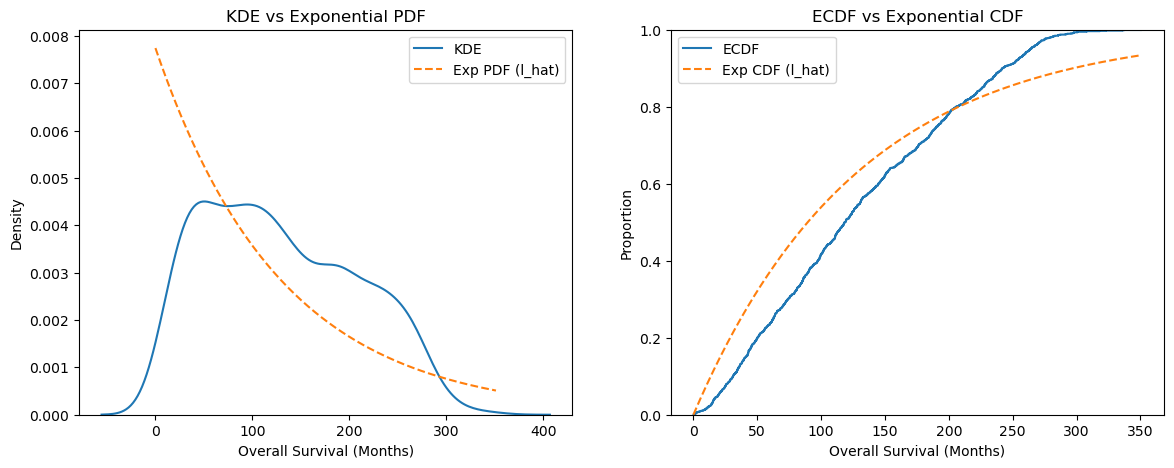

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE vs pdf
sns.kdeplot(x=y, ax=axes[0], label='KDE')
axes[0].plot(grid, pdf, linestyle='--', label='Exp PDF (l_hat)')
axes[0].set_title('KDE vs Exponential PDF')
axes[0].legend()

# ECDF vs cdf
sns.ecdfplot(x=y, ax=axes[1], label='ECDF')
axes[1].plot(grid, cdf, linestyle='--', label='Exp CDF (l_hat)')
axes[1].set_title('ECDF vs Exponential CDF')
axes[1].legend()

plt.show()

KDE : Very poor fit, data is not monotone decreasing

ECDF: Not nearly as bad, but underestimates short times and overestimates long times

In [38]:
S = 5000

def mle_lambda(y):
    return 1 / y.mean()

boot_lambdas = [
    mle_lambda(y.sample(frac=1.0, replace=True))
    for s in range(S)
]

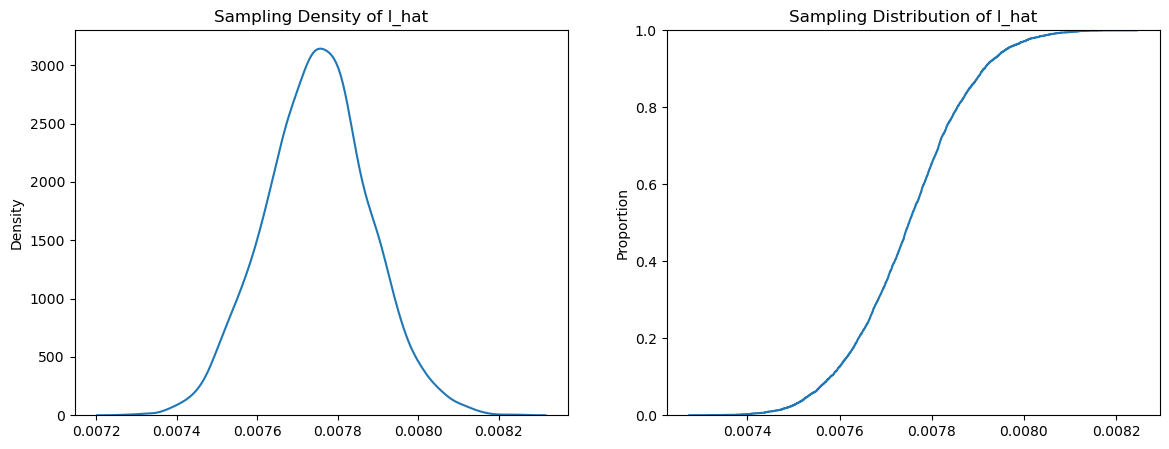

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(x=boot_lambdas, ax=axes[0])
axes[0].set_title('Sampling Density of l_hat')
sns.ecdfplot(x=boot_lambdas, ax=axes[1])
axes[1].set_title('Sampling Distribution of l_hat')
plt.show()

## 11.
- Open the Ames house price data. Make a histogram of 'TotRms.AbvGrd', or total rooms above ground.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

Likelihood:

$$
L(\lambda)
  = \prod_{i=1}^n
    \frac{\lambda^{y_i} e^{-\lambda}}{y_i!}
  = \lambda^{\sum_i y_i}
    e^{-n\lambda}
    \prod_{i=1}^n \frac{1}{y_i!}.
$$

Log-likelihood:

$$
\ell(\lambda)
  = \left(\sum_i y_i\right)\log\lambda
    - n\lambda
    - \sum_i \log(y_i!).
$$

Derivative:

$$
\frac{d\ell}{d\lambda}
  = \frac{\sum_i y_i}{\lambda} - n = 0
$$

$$
\hat{\lambda}
  = \frac{1}{n}\sum_{i=1}^n y_i.
$$


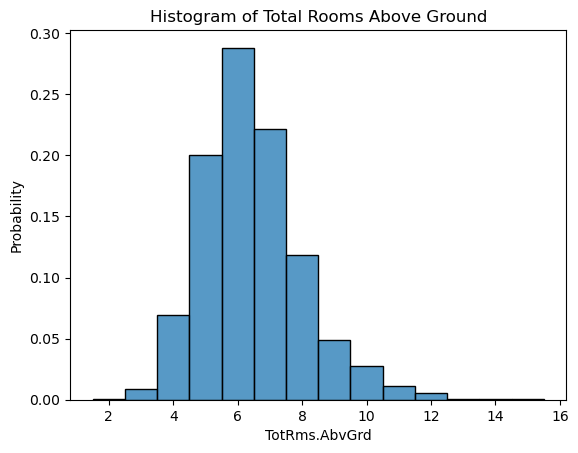

In [40]:
df = pd.read_csv('./data/ames_prices.csv')
y = df['TotRms.AbvGrd'].dropna()

sns.histplot(y, discrete=True, stat='probability')
plt.xlabel('TotRms.AbvGrd')
plt.title('Histogram of Total Rooms Above Ground')
plt.show()

In [41]:
lambda_hat = y.mean()
print('MLE l_hat:', lambda_hat)

MLE l_hat: 6.443003412969284


In [42]:
k_vals = np.arange(y.min(), y.max() + 1)

pmf = sp.stats.poisson.pmf(k_vals, mu=lambda_hat)
cdf = sp.stats.poisson.cdf(k_vals, mu=lambda_hat)

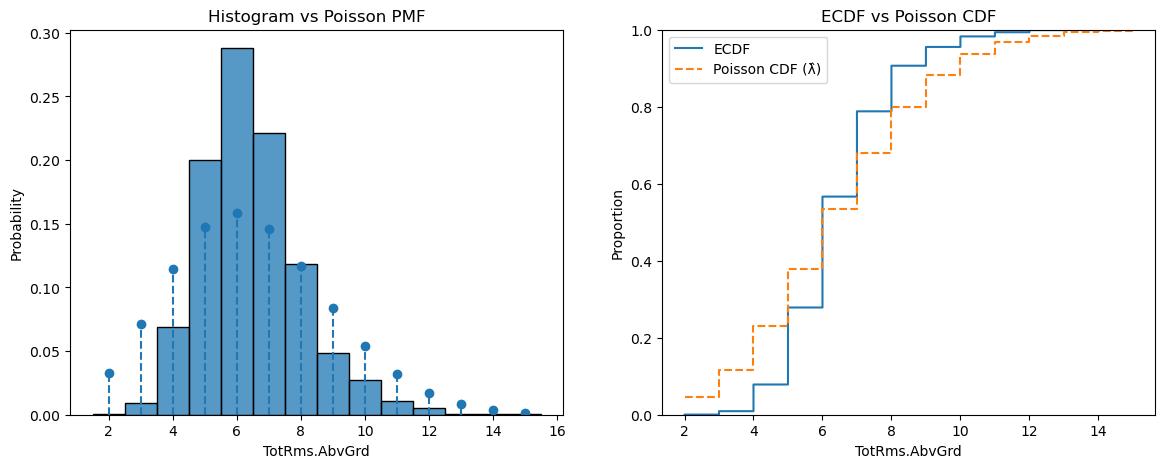

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram vs pmf
sns.histplot(y, stat='probability', discrete=True, ax=axes[0], bins=len(k_vals))
axes[0].stem(k_vals, pmf, linefmt='--', markerfmt='o', basefmt=' ')
axes[0].set_title('Histogram vs Poisson PMF')

# ECDF vs CDF
sns.ecdfplot(y, ax=axes[1], label='ECDF')
axes[1].step(k_vals, cdf, where='post', linestyle='--', label='Poisson CDF (λ̂)')
axes[1].set_title('ECDF vs Poisson CDF')
axes[1].legend()

plt.show()

Histogram: off on the tails. it overpredicts the 'width' of the distribution. IDK if i said that right.

ECDF: The poisson is a bit less steep, but aligns ok.

## 12.
- Open the METABRIC data. Make a histogram of 'Mutation Count' with around 50 bins. Let $Y$ be the mutation count the random variable, and $y_i$ the mutation count for patient $i$.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

Likelihood:

$$
L(\lambda)
  = \prod_{i=1}^n
    \frac{\lambda^{y_i} e^{-\lambda}}{y_i!}
  = \lambda^{\sum_i y_i}
    e^{-n\lambda}
    \prod_{i=1}^n \frac{1}{y_i!}.
$$

Log-likelihood:

$$
\ell(\lambda)
  = \left(\sum_i y_i\right)\log\lambda
    - n\lambda
    - \sum_i \log(y_i!).
$$

MLE:

$$
\hat{\lambda}
  = \frac{1}{n}\sum_{i=1}^n y_i.
$$


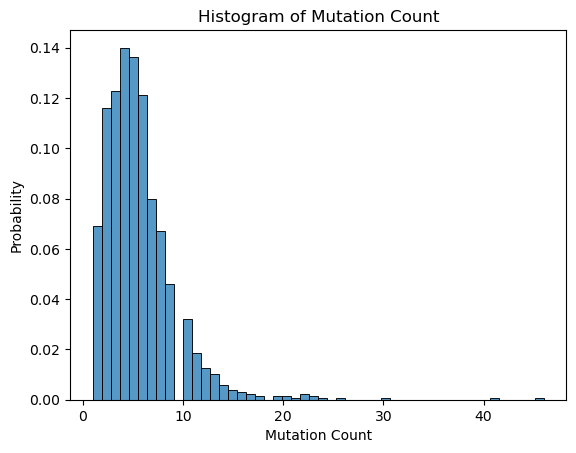

In [44]:
df = pd.read_csv('./data/metabric.csv')
y = df['Mutation Count'].dropna()

sns.histplot(y, bins=50, stat='probability')
plt.xlabel('Mutation Count')
plt.title('Histogram of Mutation Count')
plt.show()

In [45]:
lambda_hat = y.mean()
print('MLE l_hat:', lambda_hat)

MLE l_hat: 5.494415487714073


In [46]:
k_vals = np.arange(y.min(), y.max() + 1)

pmf = sp.stats.poisson.pmf(k_vals, mu=lambda_hat)
cdf = sp.stats.poisson.cdf(k_vals, mu=lambda_hat)

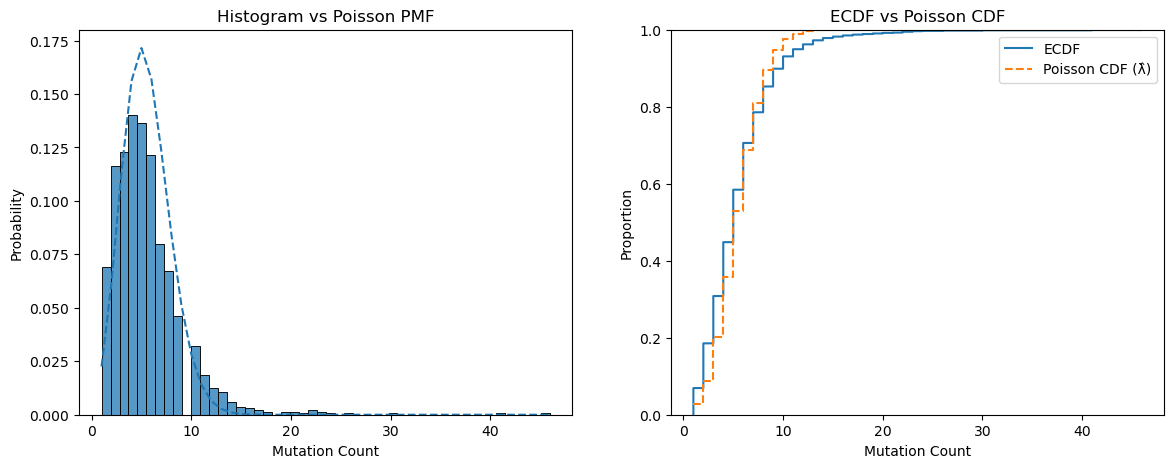

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram vs pmf
sns.histplot(y, stat='probability', bins=50, ax=axes[0])
axes[0].plot(k_vals, pmf, linestyle='--')
axes[0].set_title('Histogram vs Poisson PMF')

# ECDF vs CDF
sns.ecdfplot(y, ax=axes[1], label='ECDF')
axes[1].step(k_vals, cdf, where='post', linestyle='--', label='Poisson CDF (λ̂)')
axes[1].set_title('ECDF vs Poisson CDF')
axes[1].legend()

plt.show()

Histogram: This looks pretty good, despite being a bit skewed to the left

ECDF: This also actually looks pretty good, with the poisson being only slightly steeper than the ecdf

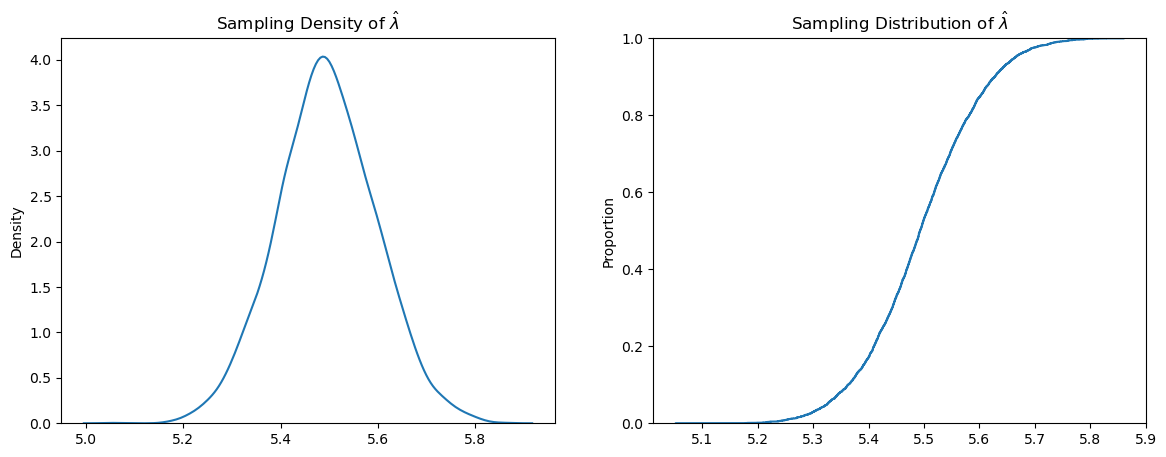

In [48]:
S = 5000

def mle_lambda(y):
    return y.mean()

boot_lambdas = [
    mle_lambda(y.sample(frac=1.0, replace=True))
    for s in range(S)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(x=boot_lambdas, ax=axes[0])
axes[0].set_title('Sampling Density of $\\hat{\\lambda}$')
sns.ecdfplot(x=boot_lambdas, ax=axes[1])
axes[1].set_title('Sampling Distribution of $\\hat{\\lambda}$')
plt.show()
